In [1]:
import os
import sys
import django

# Add project root to path and configure Django
sys.path.insert(0, os.path.dirname(os.getcwd()))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'settings.settings')
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'
django.setup()

In [2]:
import pandas as pd
from jobs.models import Job, ExtendedJob

## 1. Load Raw Data

In [3]:
# Query jobs that have extended job data using select_related for efficiency
jobs_with_extended = ExtendedJob.objects.select_related('job').values(
    'job__title',
    'job_category',
    'job__company',
    'job__location',
    'job__salary',
    'bachelor_required',
    'master_required',
    'phd_required',
    'tech_stack',
    'min_experience_years',
    'us_only',
    'employment_type',
    'medical_insurance',
)

# Convert to DataFrame
df = pd.DataFrame(list(jobs_with_extended))

# Rename columns to remove the 'job__' prefix
df.columns = [
    'title',
    'job_category',
    'company',
    'location',
    'salary',
    'bachelor_required',
    'master_required',
    'phd_required',
    'tech_stack',
    'min_experience_years',
    'us_only',
    'employment_type',
    'medical_insurance',
]

df

,title,job_category,company,location,salary,bachelor_required,master_required,phd_required,tech_stack,min_experience_years,us_only,employment_type,medical_insurance
0,Service Desk Support Analyst III - Kelsey - Se...,HD,Optum,", US, TXPearland",$28.94 - $51.63 an hour,True,False,False,"windows,active directory,microsoft office,wan,...",4,True,full-time,True
1,Principal Enterprise Architect (Remote),SSWE,IQVIA,", US, NJWayne","$118,100 - $328,800 a year",True,False,False,"Kafka,Apigee,Azure API Management,Kong,Azure M...",15,True,full-time,True
2,Senior Technical Program Manager (ST PM) (15.35),PM,"OCT Consulting, LLC",", US, DCWashington","$175,000 - $250,000 a year",True,False,False,"aws,cloud,cybersecurity,agile,itil,cmmi,pmboK",8,True,full-time,True
3,Cloud Cybersecurity Manager (CCM) (15.35),DevOps,"OCT Consulting, LLC",", US, DCWashington","$150,000 - $225,000 a year",True,False,False,"aws,cloud,cybersecurity,zerotrust,nist,stigs,s...",8,True,full-time,True
4,Cloud Architect and Infrastructure Lead (CAIL)...,DevOps,"OCT Consulting, LLC",", US, DCWashington","$150,000 - $200,000 a year",True,False,False,"aws,devsecops,agile,cybersecurity",6,True,full-time,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1907,"Senior Staff Software Engineer, Backend (Consu...",SSWE,Coinbase,", USRemote","$246,500 - $290,000 a year",True,False,False,"go,temporal,kubernetes,mongodb",10,False,full-time,True
1908,"Staff Software Engineer, Backend (Consumer - T...",SSWE,Coinbase,", USRemote","$218,025 - $256,500 a year",False,False,False,"golang,clickhouse,kafka,redis,mongodb",8,False,full-time,True
1909,Engineering Manager (Consumer - Growth),EM,Coinbase,", USRemote","$218,025 - $256,500 a year",False,False,False,NaN,7,False,full-time,True
1910,"Senior Staff Software Engineer, Backend (Consu...",SSWE,Coinbase,", USRemote","$253,895 - $298,700 a year",False,False,False,NaN,0,False,full-time,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   title                 1912 non-null   str   
 1   job_category          1912 non-null   str   
 2   company               1912 non-null   str   
 3   location              1912 non-null   str   
 4   salary                1912 non-null   str   
 5   bachelor_required     1912 non-null   bool  
 6   master_required       1912 non-null   bool  
 7   phd_required          1912 non-null   bool  
 8   tech_stack            1637 non-null   str   
 9   min_experience_years  1912 non-null   int64 
 10  us_only               1912 non-null   bool  
 11  employment_type       1845 non-null   str   
 12  medical_insurance     1907 non-null   object
dtypes: bool(4), int64(1), object(1), str(7)
memory usage: 142.0+ KB


## 2. Clean Cols

### 2.1 Clean: Salary

In [5]:
print(df['salary'].sample(30).to_string())

1180          $105,000 - $120,000 a year
196           $160,000 - $220,000 a year
1267                     $130,000 a year
1050            $60,700 - $99,700 a year
1843          $238,000 - $280,000 a year
1255          $200,000 - $300,000 a year
1382          $158,000 - $248,000 a year
1199          $165,000 - $175,000 a year
832           $167,000 - $203,000 a year
868           $185,250 - $271,700 a year
11               $6,521 - $8,769 a month
1085    $100,339.20 - $140,462.40 a year
1539            $51,500 - $86,000 a year
781           $168,000 - $192,000 a year
661             $80,000 - $90,000 a year
34            $129,590 - $178,250 a year
312           $137,700 - $275,400 a year
1516          $196,600 - $337,100 a year
1317          $100,800 - $144,000 a year
283           $125,000 - $145,000 a year
1808          $112,000 - $179,000 a year
1024          $154,500 - $224,540 a year
477           $129,000 - $207,000 a year
1612           $80,000 - $132,000 a year
423           $1

In [6]:
import re

def clean_salary_to_hourly(salary_str):
    """
    Convert salary string to hourly rate (float).
    - Removes $ and , symbols
    - Averages MIN-MAX ranges
    - Converts monthly (200-40k) and annual (>40k) to hourly
    """
    if pd.isna(salary_str) or not salary_str:
        return None
    
    # Remove $ and , symbols
    cleaned = salary_str.replace('$', '').replace(',', '')
    
    # Extract all numbers (including decimals)
    numbers = re.findall(r'[\d.]+', cleaned)
    
    if not numbers:
        return None
    
    # Convert to floats
    values = [float(n) for n in numbers]
    
    # Average if range (MIN-MAX)
    salary = sum(values) / len(values)
    
    # Convert to hourly based on value thresholds
    if salary < 200:
        # Already hourly
        hourly = salary
    elif salary < 40000:
        # Monthly -> divide by 173.33
        hourly = salary / 173.33
    else:
        # Annual -> divide by 2080
        hourly = salary / 2080
    
    return round(hourly, 2)

# Apply the cleaning function
df['salary_hourly'] = df['salary'].apply(clean_salary_to_hourly)

# Show sample of original vs cleaned
df[['salary', 'salary_hourly']].head(10)

,salary,salary_hourly
0,$28.94 - $51.63 an hour,40.29
1,"$118,100 - $328,800 a year",107.43
2,"$175,000 - $250,000 a year",102.16
3,"$150,000 - $225,000 a year",90.14
4,"$150,000 - $200,000 a year",84.13
5,"$120,001 - $160,000 a year",67.31
6,"$140,000 - $165,000 a year",73.32
7,"$111,000 - $156,500 a year",64.30
8,"$105,000 - $125,000 a year",55.29
9,"$45,000 - $110,000 a year",37.26


In [7]:
df["salary"] = df["salary_hourly"]
df.drop(columns="salary_hourly", inplace=True)

### 2.2 Clean: Employment type

In [8]:
df['employment_type'].unique()

<StringArray>
[         'full-time',           'contract',           'flexible',
                  nan,         'internship',          'part-time',
 'full-time,contract']
Length: 7, dtype: str

In [9]:
# Clean employment_type: keep only the first value if multiple exist
df['employment_type'] = df['employment_type'].str.split(',').str[0]

df['employment_type'].unique()

array(['full-time', 'contract', 'flexible', nan, 'internship',
       'part-time'], dtype=object)

### 2.3 Clean: Location

In [10]:
df['location'].unique()

<StringArray>
[     ', US, TXPearland',         ', US, NJWayne',    ', US, DCWashington',
       ', US, TXEl Paso',        ', US, TXIrving',        ', US, TXAustin',
  ', US, CAPort Hueneme',  ', US, COFort Collins',       ', US, VAFairfax',
       ', US, WAPullman',
 ...
       ', US, MIZeeland',          ', US, MSnull',     ', US, FLLake Mary',
    ', US, MASomerville',    ', US, OHCincinnati', ', US, OKOklahoma City',
   ', US, MNMaple Grove', ', US, ILDowners Grove',     ', US, NYGreenwich',
    ', US, ALBirmingham']
Length: 296, dtype: str

In [11]:
print(df['location'].sample(30).to_string())

1812               , USRemote
860          , US, IDLewiston
1798          , US, WIMadison
1824             , US, OKnull
324                , USRemote
425                , USRemote
877          , US, CASan Jose
149       , US, CAMorgan Hill
1800               , USRemote
922                , USRemote
1725               , USRemote
1546               , USRemote
1455               , USRemote
256              , US, INnull
1781               , USRemote
1094           , US, ILUrbana
449                , USRemote
473                , USRemote
687                , USRemote
1779          , US, COBoulder
1331               , USRemote
899     , US, CASan Francisco
752            , US, CODenver
1258          , US, VAAshburn
1511         , US, NYNew York
85               , US, TXnull
1793               , USRemote
480                  , USnull
193                , USRemote
1261          , US, WASeattle


In [12]:
def clean_location(loc_str):
    """
    Clean location to format: "US" or "US, Remote" or "US, STATE"
    
    Input formats:
    - ', US, TXPearland' -> 'US, TX'
    - ', USRemote' -> 'US, Remote'
    - ', US, MSnull' -> 'US, MS'
    - ', USnull' -> 'US'
    """
    if pd.isna(loc_str) or not loc_str:
        return 'US'
    
    # Remove leading comma and spaces
    cleaned = loc_str.strip().lstrip(',').strip()
    
    # Check for Remote
    if 'Remote' in cleaned:
        return 'US, Remote'
    
    # Check for just "USnull" (no state)
    if cleaned == 'USnull':
        return 'US'
    
    # Pattern: "US, STATEcity" - extract state code (2 letters after "US, ")
    if ', ' in cleaned:
        parts = cleaned.split(', ')
        if len(parts) >= 2:
            state_city = parts[1]
            # Extract first 2 characters as state code
            state = state_city[:2].upper()
            return f'US, {state}'
    
    return 'US'

# Apply the cleaning function
df['location'] = df['location'].apply(clean_location)

# Check unique values
df['location'].unique()

<StringArray>
[    'US, TX',     'US, NJ',     'US, DC',     'US, CA',     'US, CO',
     'US, VA',     'US, WA',     'US, MN',     'US, UT',     'US, FL',
     'US, GA',     'US, MA',     'US, IL',     'US, OH',     'US, WV',
     'US, AZ',     'US, SC',     'US, NC', 'US, Remote',         'US',
     'US, IN',     'US, MD',     'US, MI',     'US, NY',     'US, KY',
     'US, ME',     'US, NV',     'US, NM',     'US, PA',     'US, OR',
     'US, NH',     'US, CT',     'US, MO',     'US, WI',     'US, OK',
     'US, TN',     'US, KS',     'US, LA',     'US, RI',     'US, NE',
     'US, ND',     'US, IA',     'US, MT',     'US, VT',     'US, ID',
     'US, AL',     'US, WY',     'US, MS']
Length: 48, dtype: str

### 2.4 Clean: Medical Insurance

In [13]:
# Fill None values with False and convert to bool
df['medical_insurance'] = df['medical_insurance'].fillna(False).astype(bool)

df['medical_insurance'].dtype

dtype('bool')

## 3. EDA

### 3.1 NA/None counts for all columns

In [14]:
df.isna().sum()

title                     0
job_category              0
company                   0
location                  0
salary                    0
bachelor_required         0
master_required           0
phd_required              0
tech_stack              275
min_experience_years      0
us_only                   0
employment_type          67
medical_insurance         0
dtype: int64

### 3.2 AVG salary 

In [15]:
print(df['salary'].mean())

71.75748953974896


In [16]:
df.groupby('job_category')['salary'].mean().sort_values(ascending=False).round(2)

job_category
C         105.40
EM         97.45
SSWE       89.40
MLE        87.42
UI         79.79
DE         73.11
PM         71.22
TL         71.02
SWE        70.82
DevOps     67.91
QA         59.31
Other      53.71
DA         51.89
HD         39.60
Name: salary, dtype: float64

### 3.3 job_category count

In [17]:
df['job_category'].value_counts()

job_category
SWE       329
PM        310
DevOps    239
Other     174
SSWE      171
MLE       130
DA        121
DE        117
EM         95
HD         67
C          46
UI         44
QA         35
TL         34
Name: count, dtype: int64

### 3.4 Education level count

In [18]:
education_counts = pd.DataFrame({
    'bachelor_required': [df['bachelor_required'].sum()],
    'master_required': [df['master_required'].sum()],
    'phd_required': [df['phd_required'].sum()]
}).T
education_counts.columns = ['count']
education_counts['percentage'] = (education_counts['count'] / len(df) * 100).round(2)
education_counts

,count,percentage
bachelor_required,1079,56.43
master_required,50,2.62
phd_required,2,0.10


### 3.5 Education level average salary

In [19]:
education_salary = pd.DataFrame({
    'bachelor_required': [df[df['bachelor_required']]['salary'].mean()],
    'master_required': [df[df['master_required']]['salary'].mean()],
    'phd_required': [df[df['phd_required']]['salary'].mean()]
}).T
education_salary.columns = ['avg_salary']
education_salary.round(2)

,avg_salary
bachelor_required,73.26
master_required,90.75
phd_required,47.64


### 3.6 Company count

In [20]:
df['company'].value_counts().head(20)

company
CVS Health                                 27
Humana                                     23
World Wide Technology Holding, LLC         21
General Dynamics Information Technology    20
Gainwell Technologies LLC                  19
Concentrix                                 18
Atlassian                                  17
Netflix                                    15
Centene                                    14
Dropbox                                    14
Optum                                      13
FBG Enterprises Opco, LLC                  10
Waymo                                      10
MetroStar                                  10
NTT DATA                                   10
SAIC                                        9
GitHub                                      9
Odixcity Consulting                         9
The College Board                           9
ATPCO                                       9
Name: count, dtype: int64

### 3.7 Company average salary

In [21]:
df.groupby('company')['salary'].mean().sort_values(ascending=False).head(20).round(2)

company
Vi-M Professional Solutions           360.58
Odixcity Consulting                   240.38
Bigged                                240.38
PyStrap Technologies                  240.38
Fave Technologies Limited             240.38
Netflix                               228.04
Advanced Monitored Caregiving Inc.    210.00
59 Pines                              168.27
SupplyHouse                           164.90
Koloxo West Africa                    156.25
YIP Online Limited                    156.25
MCG Health                            154.90
Prolific                              150.00
Veeam Software                        149.18
GoPro                                 146.73
HighLevel                             145.43
Dr. Berg Nutritionals                 145.00
BHG Financial                         144.23
RSM                                   143.63
Alteryx                               137.02
Name: salary, dtype: float64

## 4. Encoding

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 1912 non-null   str    
 1   job_category          1912 non-null   str    
 2   company               1912 non-null   str    
 3   location              1912 non-null   str    
 4   salary                1912 non-null   float64
 5   bachelor_required     1912 non-null   bool   
 6   master_required       1912 non-null   bool   
 7   phd_required          1912 non-null   bool   
 8   tech_stack            1637 non-null   str    
 9   min_experience_years  1912 non-null   int64  
 10  us_only               1912 non-null   bool   
 11  employment_type       1845 non-null   object 
 12  medical_insurance     1912 non-null   bool   
dtypes: bool(5), float64(1), int64(1), object(1), str(5)
memory usage: 129.0+ KB


In [23]:
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder

# Create a copy for encoding
df_encoded = df.copy()

# 1. Drop title (too noisy, job_category already captures role info)
df_encoded = df_encoded.drop(columns=['title'])

# 2. Target encode high/medium cardinality categoricals
target_cols = ['job_category', 'company', 'location']
te = TargetEncoder(cols=target_cols, smoothing=10)
df_encoded[target_cols] = te.fit_transform(df_encoded[target_cols], df_encoded['salary'])

# 3. One-hot encode employment_type (low cardinality, handles NaN)
df_encoded = pd.get_dummies(df_encoded, columns=['employment_type'], dummy_na=True)

# 4. Multi-label binarize tech_stack
df_encoded['tech_stack'] = df_encoded['tech_stack'].fillna('')
tech_lists = df_encoded['tech_stack'].str.lower().str.split(',')

# Filter to top N most common technologies to reduce noise
from collections import Counter
all_techs = [tech.strip() for techs in tech_lists for tech in techs if tech.strip()]
tech_counts = Counter(all_techs)
top_techs = {tech for tech, count in tech_counts.most_common(50)}  # Keep top 50

# Filter tech lists to only include top techs
tech_lists_filtered = tech_lists.apply(lambda x: [t.strip() for t in x if t.strip() in top_techs])

mlb = MultiLabelBinarizer()
tech_encoded = pd.DataFrame(
    mlb.fit_transform(tech_lists_filtered),
    columns=[f'tech_{t}' for t in mlb.classes_],
    index=df_encoded.index
)
df_encoded = pd.concat([df_encoded.drop(columns=['tech_stack']), tech_encoded], axis=1)

# 5. Convert ALL bool columns to int (explicit for XGBoost)
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_category                1912 non-null   float64
 1   company                     1912 non-null   float64
 2   location                    1912 non-null   float64
 3   salary                      1912 non-null   float64
 4   bachelor_required           1912 non-null   int64  
 5   master_required             1912 non-null   int64  
 6   phd_required                1912 non-null   int64  
 7   min_experience_years        1912 non-null   int64  
 8   us_only                     1912 non-null   int64  
 9   medical_insurance           1912 non-null   int64  
 10  employment_type_contract    1912 non-null   int64  
 11  employment_type_flexible    1912 non-null   int64  
 12  employment_type_full-time   1912 non-null   int64  
 13  employment_type_internship  1912 non-null   

In [24]:
# Preview encoded features
df_encoded.head()

,job_category,company,location,salary,bachelor_required,master_required,phd_required,min_experience_years,us_only,medical_insurance,...,tech_react,tech_rest,tech_salesforce,tech_snowflake,tech_sql,tech_sql server,tech_tableau,tech_terraform,tech_typescript,tech_windows
0,39.885112,76.603802,64.223308,40.29,1,0,0,4,1,1,...,0,0,0,0,0,0,0,0,0,1
1,89.403562,75.517340,68.551588,107.43,1,0,0,15,1,1,...,0,0,0,1,0,0,0,0,0,0
2,71.221387,75.314720,70.115357,102.16,1,0,0,8,1,1,...,0,0,0,0,0,0,0,0,0,0
3,67.910042,75.314720,70.115357,90.14,1,0,0,8,1,1,...,0,0,0,0,0,0,0,0,0,0
4,67.910042,75.314720,70.115357,84.13,1,0,0,6,1,1,...,0,0,0,0,0,0,0,0,0,0


## 4.1 Fix Dummy Variable Trap - VIF

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Function to calculate VIF
def calculate_vif(dataframe):
    # Add a constant to the DataFrame (intercept term)
    df_with_constant = add_constant(dataframe)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_with_constant.columns
    vif_data["VIF"] = [variance_inflation_factor(df_with_constant.values, i)
                       for i in range(df_with_constant.shape[1])]

    return vif_data

# Calculate VIF for encoded data
vif_df = calculate_vif(df_encoded)

# Show all rows ordered by VIF
with pd.option_context('display.max_rows', None):
    display(vif_df.sort_values('VIF', ascending=False))

/home/nahuel/programming/ML/tech-jobs-analysis/venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/nahuel/programming/ML/tech-jobs-analysis/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
16,employment_type_nan,inf
13,employment_type_full-time,inf
14,employment_type_internship,inf
12,employment_type_flexible,inf
11,employment_type_contract,inf
15,employment_type_part-time,inf
4,salary,5.067620
30,tech_css,4.248503
2,company,4.092492
41,tech_html,4.083355


In [26]:
df_encoded.drop(['employment_type_nan'], axis=1, inplace=True)

In [27]:
vif_df = calculate_vif(df_encoded)

with pd.option_context('display.max_rows', None):
    display(vif_df.sort_values('VIF', ascending=False))

,Feature,VIF
0,const,491.525545
4,salary,5.067620
29,tech_css,4.248503
2,company,4.092492
40,tech_html,4.083355
13,employment_type_full-time,2.396699
46,tech_kubernetes,1.969396
22,tech_aws,1.862576
63,tech_terraform,1.821871
32,tech_docker,1.814803


## 5. Correlation Matrix

In [28]:
# Calculate correlation with salary (target variable)
correlations = df_encoded.corr()['salary'].drop('salary').sort_values(key=abs, ascending=False)

# Display top correlations
print("Top 20 features correlated with salary (by absolute value):\n")
print(correlations.head(20).round(2).to_string())
print("\n" + "="*50)
print("\nBottom 10 (weakest correlations):\n")
print(correlations.tail(10).round(2).to_string())

Top 20 features correlated with salary (by absolute value):

company                       0.84
job_category                  0.42
min_experience_years          0.34
location                      0.20
tech_excel                   -0.15
tech_python                   0.13
tech_windows                 -0.12
employment_type_internship   -0.11
tech_gcp                      0.11
tech_go                       0.11
tech_jira                    -0.10
master_required               0.09
tech_c++                      0.09
tech_ai                       0.09
tech_aws                      0.09
tech_kafka                    0.09
tech_html                    -0.08
tech_java                     0.08
tech_cloud                    0.08
tech_salesforce              -0.07


Bottom 10 (weakest correlations):

tech_agile                  0.02
tech_api                   -0.02
tech_javascript            -0.02
tech_jenkins                0.01
tech_rest                  -0.01
employment_type_contract    0.01
tech

## 6. Train/Val/Test Split
Split data into Train 90%, Val 10%, Test 10%

In [29]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop(columns=['salary'])
y = df_encoded['salary']

# First split: 90% train+val, 10% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.1,
    shuffle=True,
    random_state=42
)

# Second split: ~89% train, ~11% val (of the 90% = 80% train, 10% val overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=1/9,
    shuffle=True,
    random_state=42
)

# Reset indexes for clean dataframes
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Print shapes
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Split ratios: {len(X_train)/len(df_encoded)*100:.0f}% / {len(X_val)/len(df_encoded)*100:.0f}% / {len(X_test)/len(df_encoded)*100:.0f}%")

Training set:   X=(1528, 64), y=(1528,)
Validation set: X=(192, 64), y=(192,)
Test set:       X=(192, 64), y=(192,)

Total samples: 1912
Split ratios: 80% / 10% / 10%


## 7. XGBoost Training

In [30]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

avg_salary = y_train.mean()

# Callback to print MAE% and RMSE% relative to mean salary
class PctCallback(xgb.callback.TrainingCallback):
    def __init__(self, avg):
        self.avg = avg
    def after_iteration(self, model, epoch, evals_log):
        for data, metrics in evals_log.items():
            parts = []
            for name, vals in metrics.items():
                raw = vals[-1]
                pct = (raw / self.avg) * 100
                parts.append(f'{name}: {raw:.2f} ({pct:.1f}%)')
            print(f'[{epoch}]\t{data}\t{" | ".join(parts)}')
        return False

# Create XGBoost regressor
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric=['mae', 'rmse'],
    callbacks=[PctCallback(avg_salary)]
)

# Train with validation set for early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

[0]	validation_0	mae: 20.60 (28.7%) | rmse: 26.37 (36.7%)
[1]	validation_0	mae: 19.01 (26.5%) | rmse: 24.45 (34.0%)
[2]	validation_0	mae: 17.58 (24.5%) | rmse: 22.75 (31.7%)
[3]	validation_0	mae: 16.40 (22.8%) | rmse: 21.35 (29.7%)
[4]	validation_0	mae: 15.33 (21.3%) | rmse: 20.08 (28.0%)
[5]	validation_0	mae: 15.03 (20.9%) | rmse: 19.74 (27.5%)
[6]	validation_0	mae: 14.13 (19.7%) | rmse: 18.66 (26.0%)
[7]	validation_0	mae: 13.31 (18.5%) | rmse: 17.68 (24.6%)
[8]	validation_0	mae: 12.59 (17.5%) | rmse: 16.79 (23.4%)
[9]	validation_0	mae: 12.01 (16.7%) | rmse: 16.11 (22.4%)
[10]	validation_0	mae: 11.80 (16.4%) | rmse: 15.79 (22.0%)
[11]	validation_0	mae: 11.25 (15.7%) | rmse: 15.13 (21.1%)
[12]	validation_0	mae: 10.84 (15.1%) | rmse: 14.67 (20.4%)
[13]	validation_0	mae: 10.72 (14.9%) | rmse: 14.54 (20.2%)
[14]	validation_0	mae: 10.36 (14.4%) | rmse: 14.09 (19.6%)
[15]	validation_0	mae: 10.10 (14.1%) | rmse: 13.78 (19.2%)
[16]	validation_0	mae: 9.85 (13.7%) | rmse: 13.47 (18.7%)
[17]	val

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",[<__main__.Pct...x79a68fd2c2f0>]
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = x

In [31]:
# Generate predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics
def evaluate(y_true, y_pred, name, avg_salary):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse_pct = (rmse / avg_salary) * 100
    mae_pct = (mae / avg_salary) * 100
    print(f"{name:6} - RMSE: ${rmse:5.2f} ({rmse_pct:5.1f}%), MAE: ${mae:5.2f} ({mae_pct:5.1f}%), R²: {r2:.3f}")

avg_salary = y.mean()
print(f"Model Performance (avg hourly salary: ${avg_salary:.2f})\n")
evaluate(y_train, y_train_pred, "Train", avg_salary)
evaluate(y_val, y_val_pred, "Val", avg_salary)
evaluate(y_test, y_test_pred, "Test", avg_salary)

Model Performance (avg hourly salary: $71.76)

Train  - RMSE: $ 7.09 (  9.9%), MAE: $ 5.11 (  7.1%), R²: 0.957
Val    - RMSE: $10.88 ( 15.2%), MAE: $ 7.74 ( 10.8%), R²: 0.836
Test   - RMSE: $15.73 ( 21.9%), MAE: $ 9.25 ( 12.9%), R²: 0.831


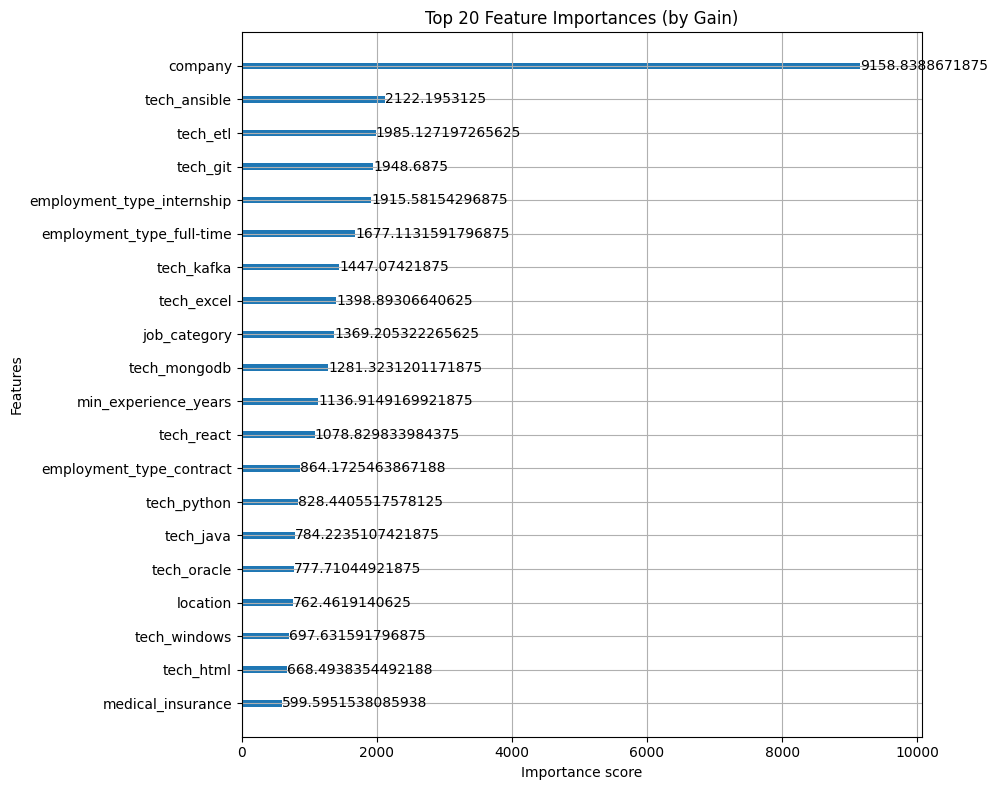

In [32]:
import matplotlib.pyplot as plt

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=20, ax=ax, importance_type='gain')
ax.set_title('Top 20 Feature Importances (by Gain)')
plt.tight_layout()
plt.show()